# 15 — Liver Tissue Expression Validation

Repeat the NB14 blood/plasma test using liver tissue expression from GTEx — genes up/down in cirrhotic or steatotic liver should align with plasma protein direction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from gtex_biomarkers.config import Config
Config.ensure_dirs()

TPM_FILE = Config.RAW_DIR / "GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct"
SA_FILE  = Config.RAW_DIR / "GTEx_Analysis_v10_Annotations_SampleAttributesDS.txt"
PATH_FILE = Config.PROCESSED_DIR / "liver_pathology_labels_imputed.csv"
ST7_FILE  = Config.RAW_DIR / "41586_2023_6592_MOESM3_ESM.xlsx"
IMP_FILE  = Config.TABLES_DIR / "pc_gene_importance_full.csv"
CACHE_FILE = Config.CACHE_DIR / "liver_tissue_tpm.parquet"

## 15.1 — Extract liver tissue TPM from GTEx

282 liver RNA-seq samples from the 19,616-sample GTEx v10 TPM matrix. Cached as parquet after first extraction.

In [2]:
if CACHE_FILE.exists():
    liver_tpm = pd.read_parquet(CACHE_FILE)
    print(f"Loaded cached liver TPM: {liver_tpm.shape}")
else:
    sa = pd.read_csv(SA_FILE, sep='\t', low_memory=False)
    liver_samps = sa[(sa['SMTS'] == 'Liver') & (sa['SMAFRZE'] == 'RNASEQ')]['SAMPID'].tolist()
    print(f"Liver RNA-seq samples: {len(liver_samps)}")

    # Read header to get column indices
    with open(TPM_FILE) as f:
        f.readline(); f.readline()  # skip GCT header lines
        header = f.readline().strip().split('\t')

    usecols = ['Name', 'Description'] + [s for s in liver_samps if s in header]
    print(f"Columns to extract: {len(usecols) - 2} liver + 2 annotation")
    print("Reading 6.8 GB TPM file (this takes a few minutes)...")

    liver_tpm = pd.read_csv(TPM_FILE, sep='\t', skiprows=2, usecols=usecols)
    liver_tpm = liver_tpm.rename(columns={'Name': 'gene_id', 'Description': 'gene_name'})
    liver_tpm.to_parquet(CACHE_FILE, index=False)
    print(f"Saved cache: {liver_tpm.shape}")

print(f"Genes: {liver_tpm.shape[0]:,}  |  Samples: {liver_tpm.shape[1] - 2}")
liver_tpm.iloc[:5, :6]

Liver RNA-seq samples: 282
Columns to extract: 262 liver + 2 annotation
Reading 6.8 GB TPM file (this takes a few minutes)...


Saved cache: (59033, 264)
Genes: 59,033  |  Samples: 262


,gene_id,gene_name,GTEX-111FC-1226-SM-HAV27,GTEX-11DXY-0526-SM-5EGGQ,GTEX-11DXZ-0126-SM-5EGGY,GTEX-11EMC-0326-SM-HAV2K
0,ENSG00000223972.5,DDX11L1,0.000000,0.017053,0.000000,0.015989
1,ENSG00000227232.5,WASH7P,3.164460,1.709570,1.965490,2.040070
2,ENSG00000278267.1,MIR6859-1,0.000000,0.000000,0.000000,0.000000
3,ENSG00000243485.5,MIR1302-2HG,0.023557,0.034047,0.049411,0.000000
4,ENSG00000237613.2,FAM138A,0.000000,0.000000,0.000000,0.000000


## 15.2 — Match samples to pathology labels

Map liver sample IDs → donor pathology. Binary split: cirrhosis (or steatosis) vs everything else in liver.

In [3]:
path_df = pd.read_csv(PATH_FILE)
# Build lookup: short sample ID → pathology
path_lookup = path_df.set_index('Tissue.Sample.ID')['Pathology.Categories.Final']

# Map TPM columns to short IDs (strip -SM-XXXXX suffix)
samp_cols = [c for c in liver_tpm.columns if c.startswith('GTEX-')]
short_map = {c: c.rsplit('-SM-', 1)[0] for c in samp_cols}

# Assign labels
labels = pd.DataFrame({
    'sampid': samp_cols,
    'short_id': [short_map[c] for c in samp_cols],
    'pathology': [path_lookup.get(short_map[c], None) for c in samp_cols],
})
labels['has_cirrhosis'] = labels['pathology'].str.contains('cirrhosis', na=False).astype(int)
labels['has_steatosis'] = labels['pathology'].str.contains('steatosis', na=False).astype(int)
labels = labels.dropna(subset=['pathology'])

print(f"Matched: {len(labels)} / {len(samp_cols)} liver samples")
print(f"Cirrhosis: {labels.has_cirrhosis.sum()} vs {(labels.has_cirrhosis == 0).sum()} rest")
print(f"Steatosis: {labels.has_steatosis.sum()} vs {(labels.has_steatosis == 0).sum()} rest")

Matched: 230 / 262 liver samples
Cirrhosis: 8 vs 222 rest
Steatosis: 127 vs 103 rest


## 15.3 — Compute liver tissue fold-change

FC = mean(TPM | disease) / mean(TPM | rest), with +1 pseudocount. Computed per gene across all 59K genes, then filtered to Olink universe.

In [4]:
import re

def compute_liver_fc(liver_tpm, labels, condition_col):
    """FC per gene: mean(disease) / mean(rest), +1 pseudocount."""
    pos_samps = labels.loc[labels[condition_col] == 1, 'sampid'].tolist()
    neg_samps = labels.loc[labels[condition_col] == 0, 'sampid'].tolist()

    tpm_mat = liver_tpm[pos_samps + neg_samps].values.astype(np.float32)
    n_pos = len(pos_samps)

    mean_pos = tpm_mat[:, :n_pos].mean(axis=1) + 1
    mean_neg = tpm_mat[:, n_pos:].mean(axis=1) + 1
    fc = mean_pos / mean_neg

    result = pd.DataFrame({
        'gene_id': liver_tpm['gene_id'].values,
        'gene_name': liver_tpm['gene_name'].values,
        'fc': fc,
        'mean_disease': mean_pos - 1,
        'mean_rest': mean_neg - 1,
    })
    result['log2fc'] = np.log2(fc)
    return result

# Cirrhosis
fc_cirr = compute_liver_fc(liver_tpm, labels, 'has_cirrhosis')
fc_cirr['fc_rank'] = fc_cirr['fc'].rank(method='first', ascending=False).astype(int)
print("=== Liver tissue FC: Cirrhosis vs rest ===")
print(f"n_pos={labels.has_cirrhosis.sum()}, n_neg={(labels.has_cirrhosis==0).sum()}")
print("\nTop-5 UP:"); print(fc_cirr.nlargest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))
print("\nTop-5 DOWN:"); print(fc_cirr.nsmallest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))

print("\n=== Liver tissue FC: Steatosis vs rest ===")
fc_steat = compute_liver_fc(liver_tpm, labels, 'has_steatosis')
fc_steat['fc_rank'] = fc_steat['fc'].rank(method='first', ascending=False).astype(int)
print(f"n_pos={labels.has_steatosis.sum()}, n_neg={(labels.has_steatosis==0).sum()}")
print("\nTop-5 UP:"); print(fc_steat.nlargest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))
print("\nTop-5 DOWN:"); print(fc_steat.nsmallest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))

=== Liver tissue FC: Cirrhosis vs rest ===
n_pos=8, n_neg=222

Top-5 UP:
gene_name        fc   log2fc
    HSPA6 17.223858 4.106337
    STMN2 14.111816 3.818832
    HSPA7 12.783006 3.676155
    MMP11 11.952629 3.579256
    KRT23 11.173563 3.482017

Top-5 DOWN:
gene_name       fc    log2fc
     MT1B 0.108377 -3.205869
   CYP1A2 0.147415 -2.762041
LINC01595 0.150328 -2.733814
   CYP1A1 0.158315 -2.659133
    GSTA2 0.179255 -2.479918

=== Liver tissue FC: Steatosis vs rest ===
n_pos=127, n_neg=103

Top-5 UP:
      gene_name       fc   log2fc
         EEF1A2 3.818033 1.932829
          APOA4 2.261884 1.177525
          MUC13 2.180722 1.124806
      LINC02158 1.986411 0.990164
ENSG00000281383 1.907097 0.931378

Top-5 DOWN:
gene_name       fc    log2fc
    IFI27 0.285627 -1.807795
   CXCL13 0.391030 -1.354648
  SLC2A14 0.401904 -1.315076
      PGC 0.413527 -1.273946
     POMC 0.516662 -0.952708


## 15.4 — Intersect with Olink universe + attach UKB-PPP ALT BETA

Same 2,941-protein Olink panel from Sun et al. ST7. Restrict liver FC to genes measurable in plasma.

In [5]:
st7 = pd.read_excel(ST7_FILE, sheet_name='ST7', header=None)
top, sub = st7.iloc[3].ffill(), st7.iloc[4]
_PREFIX = re.compile(r'^[A-Z][0-9]{1,3}[A-Z0-9]?_')

def _flatten(t, s):
    t = '' if pd.isna(t) else str(t).strip()
    s = '' if pd.isna(s) else str(s).strip()
    if not s: return t
    if not t: return s
    return f"{t}|{_PREFIX.sub('', s)}"

st7_data = st7.iloc[5:].copy()
st7_data.columns = [_flatten(t, s) for t, s in zip(top, sub)]
st7_data = st7_data.reset_index(drop=True)
st7_data['gene_symbol'] = st7_data['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
for c in [c for c in st7_data.columns if '|' in c]:
    st7_data[c] = pd.to_numeric(st7_data[c], errors='coerce')

ALT_BETA = 'ALT (liver function)|BETA'
ALT_LOG  = 'ALT (liver function)|log10(p)'
AST_BETA = 'AST (liver function)|BETA'
AST_LOG  = 'AST (liver function)|log10(p)'

st7_lookup = (st7_data[['gene_symbol', ALT_BETA, ALT_LOG, AST_BETA, AST_LOG]]
              .assign(_s=lambda d: d[[ALT_LOG, AST_LOG]].max(axis=1))
              .sort_values('_s', ascending=False).drop_duplicates('gene_symbol').drop(columns='_s'))
olink_genes = set(st7_lookup['gene_symbol'])
print(f"Olink panel: {len(olink_genes)} unique gene symbols")

Olink panel: 2923 unique gene symbols


In [6]:
def build_universe(fc_df, st7_lookup, olink_genes, condition_name):
    """Intersect liver FC with Olink panel, attach UKB-PPP BETA."""
    uni = fc_df[fc_df['gene_name'].isin(olink_genes)].copy().reset_index(drop=True)
    uni = uni.merge(st7_lookup, left_on='gene_name', right_on='gene_symbol', how='left')
    uni['fc_rank_olink'] = uni['fc'].rank(method='first', ascending=False).astype(int)
    print(f"{condition_name}: {len(uni)} genes in Olink universe (of {len(fc_df):,} total)")
    return uni

uni_cirr  = build_universe(fc_cirr,  st7_lookup, olink_genes, "Cirrhosis")
uni_steat = build_universe(fc_steat, st7_lookup, olink_genes, "Steatosis")

Cirrhosis: 2898 genes in Olink universe (of 59,033 total)
Steatosis: 2898 genes in Olink universe (of 59,033 total)


## 15.5 — Rank enrichment: liver tissue FC gene sets in UKB-PPP ALT ranking

Signed GSEA: top-100 UP / top-100 DOWN liver-tissue FC genes tested against the Olink universe sorted by sign(BETA) × −log10(p).

In [7]:
def gsea_signed(set_genes, ordered_genes, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    hit = np.array([g in set_genes for g in ordered_genes])
    nh, n = hit.sum(), len(hit)
    h, m = 1/nh, -1/(n - nh)
    rs = np.cumsum(np.where(hit, h, m))
    null = np.array([(lambda x: (x.max(), x.min()))(
        np.cumsum(np.where(rng.permutation(hit), h, m))) for _ in range(n_perm)])
    es_p, es_n = rs.max(), rs.min()
    if abs(es_p) >= abs(es_n):
        es, peak, pval = es_p, int(rs.argmax()), (null[:, 0] >= es_p).mean()
    else:
        es, peak, pval = es_n, int(rs.argmin()), (null[:, 1] <= es_n).mean()
    return dict(rs=rs, hit=hit, es=es, peak=peak, p=pval)

def run_enrichment(uni, condition, n_top=100):
    """Run GSEA for top/bottom FC genes against sign(BETA)*-log10p ranking."""
    metric = np.sign(uni[ALT_BETA].values) * uni[ALT_LOG].values
    order = np.argsort(-metric)
    sorted_genes = uni['gene_name'].values[order]
    sorted_metric = metric[order]

    top_up   = set(uni.nlargest(n_top, 'fc')['gene_name'])
    top_down = set(uni.nsmallest(n_top, 'fc')['gene_name'])

    r_up   = gsea_signed(top_up,   sorted_genes)
    r_down = gsea_signed(top_down, sorted_genes)

    # Plot
    fig = plt.figure(figsize=(12, 6))
    outer = fig.add_gridspec(1, 2, wspace=0.18)
    for col, (r, lbl, c) in enumerate([
        (r_up,   f'top-{n_top} UP in {condition} liver (highest FC)',   '#C04F4F'),
        (r_down, f'top-{n_top} DOWN in {condition} liver (lowest FC)', '#3A5670')]):
        inner = outer[col].subgridspec(3, 1, height_ratios=[4, 0.6, 1.2], hspace=0.08)
        ax1, ax2, ax3 = (fig.add_subplot(inner[i]) for i in range(3))
        x = np.arange(1, len(r['rs']) + 1)

        ax1.plot(x, r['rs'], color=c, lw=1.4)
        ax1.axhline(0, color='#666', lw=0.4, ls='--')
        ax1.scatter(r['peak']+1, r['es'], color=c, s=70, edgecolor='white', zorder=3)
        ax1.axvline(r['peak']+1, color=c, ls='--', lw=0.6, alpha=0.6)
        ax1.set_xlim(1, len(x))
        ax1.set_title(f"{lbl}\nES={r['es']:+.3f} @ rank {r['peak']+1}    p={r['p']:.0e}", fontsize=10)
        ax1.set_ylabel('running ES'); ax1.tick_params(labelbottom=False)
        ax1.spines[['top','right']].set_visible(False)

        ax2.eventplot([np.where(r['hit'])[0]+1], colors=[c], lineoffsets=[0.5],
                      linelengths=[0.95], linewidths=0.5)
        ax2.axvline(r['peak']+1, color=c, ls='--', lw=0.6, alpha=0.6)
        ax2.set_xlim(1, len(x)); ax2.set_ylim(0,1)
        ax2.set_yticks([]); ax2.tick_params(labelbottom=False, left=False)
        ax2.spines[['top','right','left']].set_visible(False)

        ax3.fill_between(x, 0, sorted_metric, color='#888', lw=0)
        ax3.axhline(0, color='#333', lw=0.4)
        ax3.axvline(r['peak']+1, color=c, ls='--', lw=0.6, alpha=0.6)
        ax3.set_xlim(1, len(x))
        ax3.set_xlabel('rank in sign(BETA)·−log10(p) (descending)')
        ax3.set_ylabel('sign·−log10p'); ax3.spines[['top','right']].set_visible(False)

    fig.suptitle(f'Liver tissue FC → UKB-PPP ALT enrichment ({condition})', y=1.02, fontsize=12)
    fig.savefig(Config.FIGURES_DIR / f'liver_tissue_fc_{condition.lower()}_alt_enrichment.pdf', bbox_inches='tight')
    plt.show()
    print(f"UP-set:   ES={r_up['es']:+.3f}  peak={r_up['peak']+1}  p={r_up['p']:.0e}")
    print(f"DOWN-set: ES={r_down['es']:+.3f}  peak={r_down['peak']+1}  p={r_down['p']:.0e}")
    return r_up, r_down

### Steatosis (n=127 vs 135 rest) — well-powered

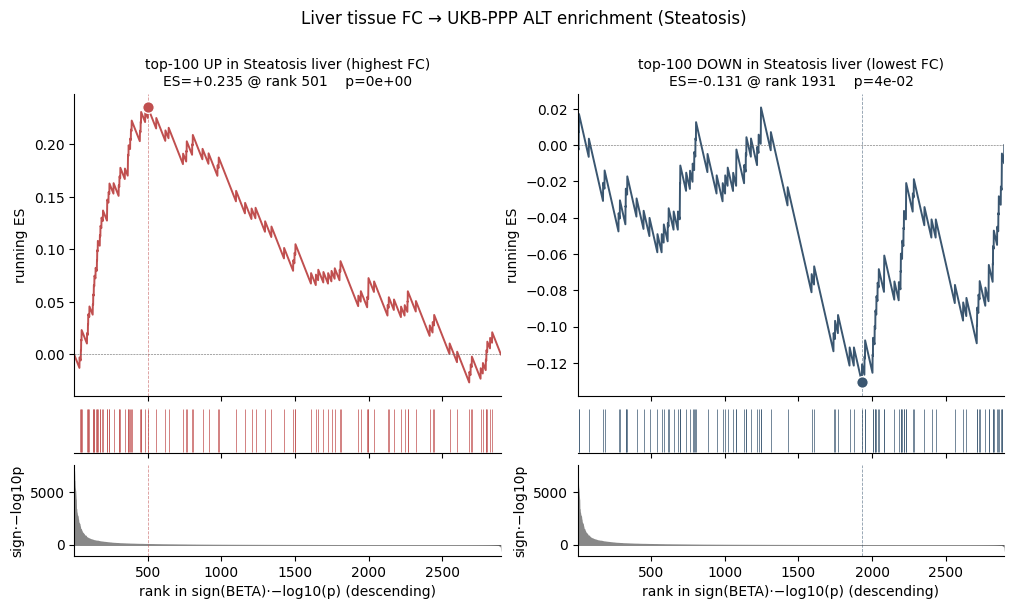

UP-set:   ES=+0.235  peak=501  p=0e+00
DOWN-set: ES=-0.131  peak=1931  p=4e-02


In [8]:
r_up_st, r_down_st = run_enrichment(uni_steat, "Steatosis")

### Cirrhosis (n=8 vs 254 rest) — low power, exploratory

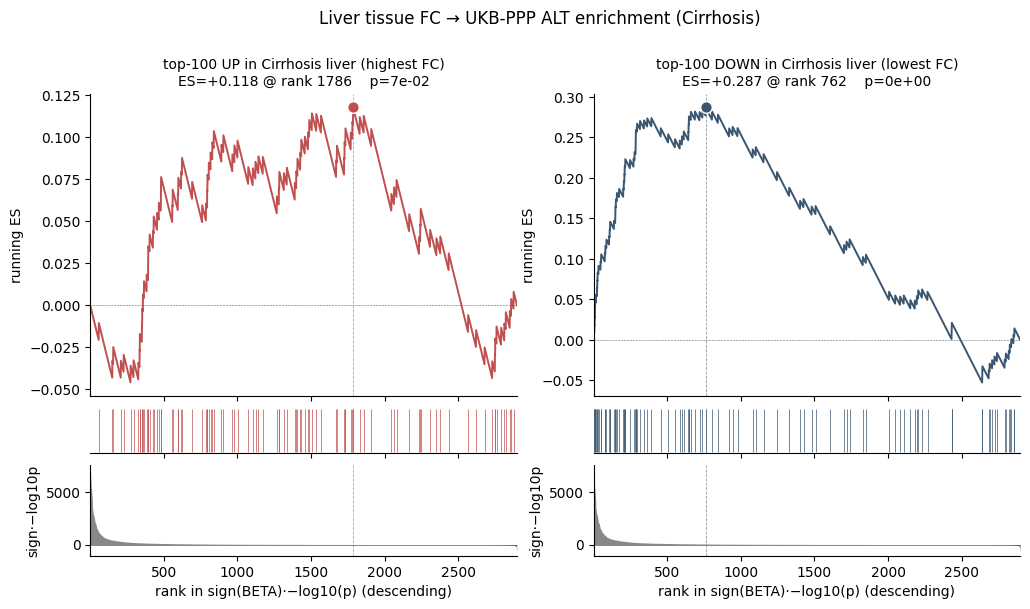

UP-set:   ES=+0.118  peak=1786  p=7e-02
DOWN-set: ES=+0.287  peak=762  p=0e+00


In [9]:
r_up_ci, r_down_ci = run_enrichment(uni_cirr, "Cirrhosis")

## 15.6 — Global Spearman: liver tissue log2FC vs UKB-PPP BETA

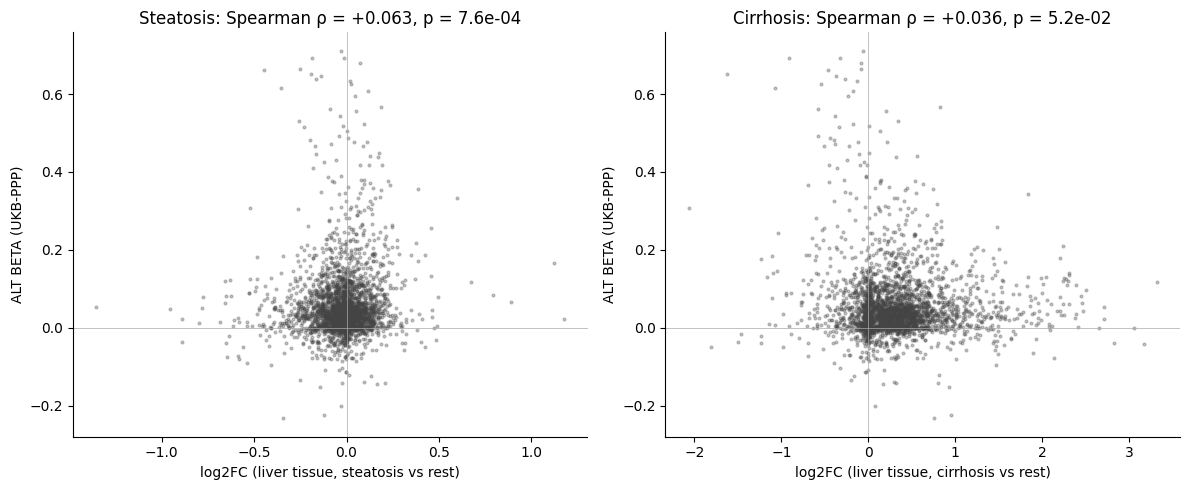

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, uni, cond in [(axes[0], uni_steat, 'Steatosis'), (axes[1], uni_cirr, 'Cirrhosis')]:
    mask = uni[ALT_BETA].notna()
    x, y = uni.loc[mask, 'log2fc'].values, uni.loc[mask, ALT_BETA].values
    rho, p = spearmanr(x, y)
    ax.scatter(x, y, s=4, alpha=0.3, color='#444')
    ax.axhline(0, color='#aaa', lw=0.5); ax.axvline(0, color='#aaa', lw=0.5)
    ax.set_xlabel(f'log2FC (liver tissue, {cond.lower()} vs rest)')
    ax.set_ylabel('ALT BETA (UKB-PPP)')
    ax.set_title(f'{cond}: Spearman ρ = {rho:+.3f}, p = {p:.1e}')
    ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'liver_tissue_fc_vs_alt_beta_scatter.pdf', bbox_inches='tight')
plt.show()

## 15.7 — Save outputs

In [11]:
T = Config.TABLES_DIR
for uni, name in [(uni_steat, 'steatosis'), (uni_cirr, 'cirrhosis')]:
    out = uni[['gene_id','gene_name','fc','log2fc','fc_rank_olink','mean_disease','mean_rest',
               ALT_BETA, ALT_LOG, AST_BETA, AST_LOG]].copy()
    out.to_csv(T / f'liver_tissue_fc_{name}_olink.csv', index=False)
    out.nlargest(100, 'fc').to_csv(T / f'liver_tissue_fc_{name}_top100_up.csv', index=False)
    out.nsmallest(100, 'fc').to_csv(T / f'liver_tissue_fc_{name}_top100_down.csv', index=False)

print("Saved: liver_tissue_fc_{steatosis,cirrhosis}_olink.csv + top100_up/down.csv")

Saved: liver_tissue_fc_{steatosis,cirrhosis}_olink.csv + top100_up/down.csv


## 15.8 — Top up / down genes for the Liver pathology pairs

Long-format CSV of top-N UP/DOWN per Liver pair, restricted to the Olink-measurable universe with UKB-PPP ALT BETA / −log10p attached, for downstream MR triage.

In [12]:
N_TOP = 100
# Scope: Liver only. Other organs will be added when their tissue TPM is extracted
# and intersected with the Olink universe in a separate workstream.
PAIRS = [
    ('Liver', 'cirrhosis', uni_cirr),
    ('Liver', 'steatosis', uni_steat),
]

rows = []
for tissue, path, uni in PAIRS:
    for d, df in [('UP', uni.nlargest(N_TOP, 'fc')), ('DOWN', uni.nsmallest(N_TOP, 'fc'))]:
        sub = df[['gene_name','fc','log2fc',ALT_BETA,ALT_LOG]].reset_index(drop=True)
        sub.insert(0, 'tissue', tissue); sub.insert(1, 'pathology', path)
        sub.insert(2, 'direction', d);   sub.insert(3, 'rank', sub.index + 1)
        sub = sub.rename(columns={ALT_BETA: 'ALT_BETA', ALT_LOG: 'ALT_log10p'})
        rows.extend(sub.to_dict('records'))

top_genes = pd.DataFrame(rows)
top_genes.to_csv(Config.TABLES_DIR / 'filtered_organs_top_genes.csv', index=False)
print(top_genes.groupby(['tissue','pathology','direction']).size().rename('n').to_string())

tissue  pathology  direction
Liver   cirrhosis  DOWN         100
                   UP           100
        steatosis  DOWN         100
                   UP           100


## 15.9 — Two-sample MR: CHI3L1 (YKL-40) → FinnGen R12 liver outcomes

Wald-ratio proof-of-concept: genetically-predicted plasma CHI3L1 (rs4950928 cis-pQTL) against six FinnGen liver phenotypes.

### 15.9.1 — Extract CHI3L1 cis-pQTL instrument

In [13]:
from scipy.stats import norm

P_THRESH = 0.05
LOG_THRESH = -np.log10(P_THRESH)

st9 = pd.read_excel(ST7_FILE, sheet_name='ST9', header=4)
st9['gene_symbol'] = st9['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
st9_sig = st9[(st9['cis/trans'] == 'cis') & (st9['log10(p) (discovery)'] > LOG_THRESH)]

chi3l1 = st9_sig[st9_sig.gene_symbol == 'CHI3L1'].iloc[0]
exp_rsid = chi3l1['rsID']
exp_beta = float(chi3l1['BETA (discovery, wrt. A1)'])
exp_se   = float(chi3l1['SE (discovery)'])
exp_A0, exp_A1 = chi3l1['Variant ID (CHROM:GENPOS (hg37):A0:A1:imp:v1)'].split(':')[2:4]

print(f"ST9 cis filter: p < {P_THRESH} (-log10p > {LOG_THRESH:.3f})  →  {len(st9_sig):,} of {(st9['cis/trans']=='cis').sum():,} cis-pQTLs retained")
print(f"{exp_rsid}:  β={exp_beta:+.4f}  SE={exp_se:.4f}  A0={exp_A0} / A1={exp_A1}  -log10(p)={chi3l1['log10(p) (discovery)']:.0f}")

ST9 cis filter: p < 0.05 (-log10p > 1.301)  →  1,955 of 1,955 cis-pQTLs retained
rs4950928:  β=+0.6720  SE=0.0090  A0=G / A1=C  -log10(p)=1204


### 15.9.2 — Wald-ratio MR: rs4950928 → FinnGen R12 liver outcomes

Sun β = +0.672 wrt A1=C → C raises plasma CHI3L1; if causal, C should also raise disease risk. Allele check per-row before Wald ratio.

In [14]:
FG_DIR = Config.RAW_DIR / 'finngen_r12'
PHENOS = [('NAFLD', 3504), ('NASH', 254), ('CIRRHOSIS_BROAD', 5545),
          ('K11_FIBROCHIRLIV', 2653), ('CHIRHEP_NAS', 1703), ('FIBROLIV', 214)]

def lookup_rsid(gz, rsid):
    for chunk in pd.read_csv(gz, sep='\t', compression='gzip', chunksize=200_000):
        h = chunk[chunk['rsids'] == rsid]
        if len(h): return h.iloc[0]
    return None

rows = []
for ph, n in PHENOS:
    v = lookup_rsid(FG_DIR / f'finngen_R12_{ph}.gz', exp_rsid)
    flip = v['alt'] != exp_A1
    b_out = (-1 if flip else 1) * float(v['beta'])
    se_out = float(v['sebeta'])
    bMR, sMR = b_out / exp_beta, se_out / abs(exp_beta)
    OR, lo, hi = np.exp(bMR), np.exp(bMR - 1.96*sMR), np.exp(bMR + 1.96*sMR)
    rows.append({
        'Phenotype': ph, 'Cases': f'{n:,}', 'flip': flip,
        'β_out': f'{b_out:+.4f}', 'SE': f'{se_out:.4f}', 'p_out': f'{float(v["pval"]):.3f}',
        'Wald β': f'{bMR:+.3f}', 'SE_MR': f'{sMR:.3f}',
        'OR (95% CI)': f'{OR:.3f} ({lo:.3f}–{hi:.3f})',
        'p_MR': f'{2*(1 - norm.cdf(abs(bMR/sMR))):.3f}',
    })

mr_chi3l1 = pd.DataFrame(rows)
mr_chi3l1.to_csv(Config.TABLES_DIR / 'mr_chi3l1_finngen_wald.csv', index=False)
print(mr_chi3l1.to_string(index=False))

       Phenotype Cases  flip   β_out     SE p_out Wald β SE_MR         OR (95% CI)  p_MR
           NAFLD 3,504 False -0.0200 0.0271 0.460 -0.030 0.040 0.971 (0.897–1.050) 0.460
            NASH   254 False +0.0493 0.1002 0.623 +0.073 0.149 1.076 (0.803–1.441) 0.623
 CIRRHOSIS_BROAD 5,545 False -0.0085 0.0216 0.694 -0.013 0.032 0.987 (0.927–1.052) 0.694
K11_FIBROCHIRLIV 2,653 False -0.0608 0.0312 0.051 -0.090 0.046 0.914 (0.834–1.000) 0.051
     CHIRHEP_NAS 1,703 False -0.0272 0.0389 0.484 -0.040 0.058 0.960 (0.857–1.076) 0.484
        FIBROLIV   214 False -0.0045 0.1091 0.967 -0.007 0.162 0.993 (0.723–1.366) 0.967


## 15.10 — MR replication on two more steatosis-UP genes: GDF15, MUC13

Same Wald-ratio pipeline applied to GDF15 (rs1054221) and MUC13 (rs1127233) from the §15.8 steatosis-UP shortlist.

In [15]:
EXTRA_GENES = ['GDF15', 'MUC13']

instruments = {}
for g in EXTRA_GENES:
    r = st9_sig[st9_sig.gene_symbol == g].iloc[0]
    A0, A1 = r['Variant ID (CHROM:GENPOS (hg37):A0:A1:imp:v1)'].split(':')[2:4]
    instruments[g] = dict(rsid=r['rsID'], beta=float(r['BETA (discovery, wrt. A1)']),
                          se=float(r['SE (discovery)']), A0=A0, A1=A1,
                          mlogp=float(r['log10(p) (discovery)']))

def mr_table(gene, inst):
    rows = []
    for ph, n in PHENOS:
        v = lookup_rsid(FG_DIR / f'finngen_R12_{ph}.gz', inst['rsid'])
        flip = v['alt'] != inst['A1']
        b_out = (-1 if flip else 1) * float(v['beta'])
        se_out = float(v['sebeta'])
        bMR, sMR = b_out / inst['beta'], se_out / abs(inst['beta'])
        OR, lo, hi = np.exp(bMR), np.exp(bMR - 1.96*sMR), np.exp(bMR + 1.96*sMR)
        rows.append({
            'Phenotype': ph, 'Cases': f'{n:,}', 'flip': flip,
            'β_out': f'{b_out:+.4f}', 'SE': f'{se_out:.4f}', 'p_out': f'{float(v["pval"]):.3f}',
            'Wald β': f'{bMR:+.3f}', 'SE_MR': f'{sMR:.3f}',
            'OR (95% CI)': f'{OR:.3f} ({lo:.3f}–{hi:.3f})',
            'p_MR': f'{2*(1 - norm.cdf(abs(bMR/sMR))):.3f}',
        })
    return pd.DataFrame(rows)

for g, inst in instruments.items():
    mr_g = mr_table(g, inst)
    mr_g.to_csv(Config.TABLES_DIR / f'mr_{g.lower()}_finngen_wald.csv', index=False)
    print(f"\n=== {g}  (rsid={inst['rsid']}, β_exp={inst['beta']:+.3f}, A0={inst['A0']}/A1={inst['A1']}) ===")
    print(mr_g.to_string(index=False))


=== GDF15  (rsid=rs1054221, β_exp=+0.392, A0=T/A1=C) ===
       Phenotype Cases  flip   β_out     SE p_out Wald β SE_MR         OR (95% CI)  p_MR
           NAFLD 3,504 False +0.0584 0.0453 0.197 +0.149 0.116 1.161 (0.925–1.456) 0.197
            NASH   254 False +0.0031 0.1669 0.985 +0.008 0.426 1.008 (0.437–2.323) 0.985
 CIRRHOSIS_BROAD 5,545 False -0.0255 0.0365 0.485 -0.065 0.093 0.937 (0.781–1.125) 0.485
K11_FIBROCHIRLIV 2,653 False -0.0896 0.0524 0.087 -0.229 0.134 0.796 (0.612–1.034) 0.087
     CHIRHEP_NAS 1,703 False -0.0971 0.0657 0.139 -0.248 0.168 0.780 (0.562–1.084) 0.139
        FIBROLIV   214 False +0.0258 0.1837 0.888 +0.066 0.469 1.068 (0.426–2.677) 0.888



=== MUC13  (rsid=rs1127233, β_exp=+0.244, A0=T/A1=G) ===
       Phenotype Cases  flip   β_out     SE p_out Wald β SE_MR         OR (95% CI)  p_MR
           NAFLD 3,504 False -0.0151 0.0304 0.620 -0.062 0.124 0.940 (0.737–1.200) 0.620
            NASH   254 False -0.0808 0.1123 0.472 -0.331 0.459 0.718 (0.292–1.768) 0.472
 CIRRHOSIS_BROAD 5,545 False -0.0064 0.0243 0.791 -0.026 0.099 0.974 (0.802–1.184) 0.791
K11_FIBROCHIRLIV 2,653 False -0.0251 0.0350 0.472 -0.103 0.143 0.902 (0.682–1.194) 0.472
     CHIRHEP_NAS 1,703 False +0.0159 0.0435 0.714 +0.065 0.178 1.067 (0.753–1.513) 0.714
        FIBROLIV   214 False -0.0450 0.1227 0.714 -0.184 0.502 0.832 (0.311–2.225) 0.714


## 15.11 — Same-direction MR sweep: steatosis-UP top-100 → 6 FinnGen liver outcomes

Keep gene-phenotype pairs where β_exp (Sun ST9) and β_out (FinnGen, A1-aligned) share the same sign — the causal-driver signature.

In [16]:
def gene_inst(g):
    h = st9_sig[st9_sig.gene_symbol == g]
    if not len(h): return None
    r = h.iloc[0]
    A0, A1 = r['Variant ID (CHROM:GENPOS (hg37):A0:A1:imp:v1)'].split(':')[2:4]
    return dict(gene=g, rsid=r['rsID'], beta_exp=float(r['BETA (discovery, wrt. A1)']),
                A0=A0, A1=A1)

def bulk_pull(gz, rsids):
    target = set(rsids); out = []
    for chunk in pd.read_csv(gz, sep='\t', compression='gzip', chunksize=500_000):
        h = chunk[chunk['rsids'].isin(target)]
        if len(h): out.append(h)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def mr_sweep_same_dir(top_file, label):
    top = pd.read_csv(top_file)
    inst = pd.DataFrame([i for g in top.gene_name if (i := gene_inst(g)) is not None])
    fg = {}
    for ph, _ in PHENOS:
        cache = Config.CACHE_DIR / f'fg_{label}_{ph}.parquet'
        if cache.exists():
            fg[ph] = pd.read_parquet(cache).drop_duplicates('rsids').set_index('rsids')
        else:
            df = bulk_pull(FG_DIR / f'finngen_R12_{ph}.gz', inst.rsid)
            df.to_parquet(cache, index=False)
            fg[ph] = df.drop_duplicates('rsids').set_index('rsids')

    rows = []
    for _, x in inst.iterrows():
        for ph, _ in PHENOS:
            if x.rsid not in fg[ph].index: continue
            v = fg[ph].loc[x.rsid]
            b_out = (-1 if v['alt'] != x.A1 else 1) * float(v['beta'])
            se_out = float(v['sebeta'])
            bMR, sMR = b_out / x.beta_exp, se_out / abs(x.beta_exp)
            rows.append(dict(Gene=x.gene, Phenotype=ph,
                             beta_exp=x.beta_exp, beta_out=b_out, SE=se_out,
                             p_out=float(v['pval']),
                             wald_beta=bMR, SE_MR=sMR,
                             p_MR=2*(1-norm.cdf(abs(bMR/sMR))),
                             same_dir=np.sign(b_out) == np.sign(x.beta_exp)))
    all_mr = pd.DataFrame(rows)
    mr = all_mr[all_mr.same_dir].drop(columns='same_dir').sort_values('p_MR').reset_index(drop=True)
    mr.to_csv(Config.TABLES_DIR / f'mr_{label}_up100_same_direction.csv', index=False)

    # Gene-level funnel
    n_start = len(top)
    n_cis   = len(inst)
    n_in_fg = inst.gene[inst.rsid.isin(set().union(*[set(fg[ph].index) for ph, _ in PHENOS]))].nunique()
    n_sig_any = all_mr[all_mr.p_out < 0.05].Gene.nunique()
    n_sd_sig  = mr[mr.p_MR < 0.05].Gene.nunique()

    print(f"=== {label.upper()} top-100 UP — gene-level funnel ===")
    print(f"  {n_start:>3}  starting genes (top-100 UP by liver FC)")
    print(f"  {n_cis:>3}  with a cis-pQTL instrument in Sun ST9        ({n_start-n_cis} dropped: no plasma cis-pQTL)")
    print(f"  {n_in_fg:>3}  rsID found in FinnGen R12                    ({n_cis-n_in_fg} dropped: rsID absent in FinnGen)")
    print(f"  {n_sig_any:>3}  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)")
    print(f"  {n_sd_sig:>3}  ALSO same-direction as plasma  ← causal candidates")
    print(f"\nCandidate genes ({n_sd_sig}): {', '.join(sorted(mr.loc[mr.p_MR<0.05, 'Gene'].unique()))}")

    print(f"\nSame-direction MR tests by phenotype:")
    print(f"  {'Phenotype':<18} {'n_tests':>8} {'p<0.05':>8}")
    for ph, _ in PHENOS:
        sub = mr[mr.Phenotype == ph]
        print(f"  {ph:<18} {len(sub):>8} {(sub.p_MR<0.05).sum():>8}")
    print(f"  {'TOTAL':<18} {len(mr):>8} {(mr.p_MR<0.05).sum():>8}")
    print(f"  (totals are gene-phenotype pairs; collapse to {n_sd_sig} unique genes since some hit multiple phenotypes)")

    print(f"\nFull same-direction MR table ({len(mr)} rows, sorted by p_MR):")
    fmt = mr.copy()
    for c in ('beta_exp','beta_out'):  fmt[c] = fmt[c].map(lambda x: f'{x:+.4f}')
    for c in ('SE','SE_MR'):           fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt['wald_beta'] = fmt['wald_beta'].map(lambda x: f'{x:+.3f}')
    for c in ('p_out','p_MR'):         fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt = fmt.rename(columns={'beta_exp':'β_exp', 'beta_out':'β_out', 'wald_beta':'Wald β'})
    print(fmt.to_string(index=False))
    return mr

mr_steat_full = mr_sweep_same_dir(Config.TABLES_DIR / 'liver_tissue_fc_steatosis_top100_up.csv', 'steatosis')

=== STEATOSIS top-100 UP — gene-level funnel ===
  100  starting genes (top-100 UP by liver FC)
   74  with a cis-pQTL instrument in Sun ST9        (26 dropped: no plasma cis-pQTL)
   70  rsID found in FinnGen R12                    (4 dropped: rsID absent in FinnGen)
   20  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
   13  ALSO same-direction as plasma  ← causal candidates

Candidate genes (13): ACHE, AGT, ALDH3A1, DNAJA4, HMOX1, HYOU1, ITGAV, LAMP2, P4HB, RET, SCGB1A1, SERPINA1, SERPINE1

Same-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    38        4
  NASH                     32        2
  CIRRHOSIS_BROAD          31        1
  K11_FIBROCHIRLIV         38        4
  CHIRHEP_NAS              40        4
  FIBROLIV                 36        3
  TOTAL                   215       18
  (totals are gene-phenotype pairs; collapse to 13 unique genes since some hit multiple phenotypes)

Full same-direction MR table (215

## 15.12 — Same-direction MR sweep: cirrhosis-UP top-100 → 6 FinnGen liver outcomes

Same pipeline and filter as §15.11 on the cirrhosis-UP top-100 list. Cache → `data/cache/fg_cirrhosis_*.parquet`; results → `output/tables/mr_cirrhosis_up100_same_direction.csv`.

In [17]:
mr_cirr_full = mr_sweep_same_dir(Config.TABLES_DIR / 'liver_tissue_fc_cirrhosis_top100_up.csv', 'cirrhosis')

=== CIRRHOSIS top-100 UP — gene-level funnel ===
  100  starting genes (top-100 UP by liver FC)
   86  with a cis-pQTL instrument in Sun ST9        (14 dropped: no plasma cis-pQTL)
   76  rsID found in FinnGen R12                    (10 dropped: rsID absent in FinnGen)
   21  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
   13  ALSO same-direction as plasma  ← causal candidates

Candidate genes (13): C7, CPXM2, DNAJA4, F2R, FSTL3, IL1RL1, IL7R, MMP7, NBL1, PIK3IP1, PODXL, SERPINH1, THBS2

Same-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    40        1
  NASH                     34        3
  CIRRHOSIS_BROAD          38        4
  K11_FIBROCHIRLIV         35        3
  CHIRHEP_NAS              35        4
  FIBROLIV                 40        0
  TOTAL                   222       15
  (totals are gene-phenotype pairs; collapse to 13 unique genes since some hit multiple phenotypes)

Full same-direction MR table (222 rows

## 15.13 — Opposite-direction MR: liver-DOWN steatosis top-100 → 6 FinnGen liver outcomes

Mirror of §15.11: top-100 DOWN-in-liver-tissue genes, kept only where cis-pQTL and FinnGen effects have opposite signs (protective-protein logic).

In [18]:
def mr_sweep_opposite_dir(top_file, label):
    """Wald MR sweep keeping rows where sign(β_out) != sign(β_exp); mirrors mr_sweep_same_dir with inverted filter and its own FinnGen cache."""
    top = pd.read_csv(top_file)
    inst = pd.DataFrame([i for g in top.gene_name if (i := gene_inst(g)) is not None])
    fg = {}
    for ph, _ in PHENOS:
        cache = Config.CACHE_DIR / f'fg_{label}_{ph}.parquet'
        if cache.exists():
            fg[ph] = pd.read_parquet(cache).drop_duplicates('rsids').set_index('rsids')
        else:
            df = bulk_pull(FG_DIR / f'finngen_R12_{ph}.gz', inst.rsid)
            df.to_parquet(cache, index=False)
            fg[ph] = df.drop_duplicates('rsids').set_index('rsids')

    rows = []
    for _, x in inst.iterrows():
        for ph, _ in PHENOS:
            if x.rsid not in fg[ph].index: continue
            v = fg[ph].loc[x.rsid]
            b_out = (-1 if v['alt'] != x.A1 else 1) * float(v['beta'])
            se_out = float(v['sebeta'])
            bMR, sMR = b_out / x.beta_exp, se_out / abs(x.beta_exp)
            rows.append(dict(Gene=x.gene, Phenotype=ph,
                             beta_exp=x.beta_exp, beta_out=b_out, SE=se_out,
                             p_out=float(v['pval']),
                             wald_beta=bMR, SE_MR=sMR,
                             p_MR=2*(1-norm.cdf(abs(bMR/sMR))),
                             opp_dir=np.sign(b_out) == -np.sign(x.beta_exp)))
    all_mr = pd.DataFrame(rows)
    mr = all_mr[all_mr.opp_dir].drop(columns='opp_dir').sort_values('p_MR').reset_index(drop=True)
    mr.to_csv(Config.TABLES_DIR / f'mr_{label}_opposite_direction.csv', index=False)

    n_start = len(top)
    n_cis   = len(inst)
    n_in_fg = inst.gene[inst.rsid.isin(set().union(*[set(fg[ph].index) for ph, _ in PHENOS]))].nunique()
    n_sig_any = all_mr[all_mr.p_out < 0.05].Gene.nunique()
    n_opp_sig = mr[mr.p_MR < 0.05].Gene.nunique()
    print(f'=== {label.upper()} OPPOSITE-direction — gene-level funnel ===')
    print(f'  {n_start:>3}  starting genes (top-100 DOWN by FC)')
    print(f'  {n_cis:>3}  with a cis-pQTL instrument in Sun ST9        ({n_start-n_cis} dropped: no plasma cis-pQTL)')
    print(f'  {n_in_fg:>3}  rsID found in FinnGen R12                    ({n_cis-n_in_fg} dropped: rsID absent in FinnGen)')
    print(f'  {n_sig_any:>3}  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)')
    print(f'  {n_opp_sig:>3}  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates')
    print(f'\nProtective candidate genes ({n_opp_sig}): ' + ', '.join(sorted(mr.loc[mr.p_MR<0.05, 'Gene'].unique())))

    print(f'\nOpposite-direction MR tests by phenotype:')
    print(f"  {'Phenotype':<18} {'n_tests':>8} {'p<0.05':>8}")
    for ph, _ in PHENOS:
        sub = mr[mr.Phenotype == ph]
        print(f'  {ph:<18} {len(sub):>8} {(sub.p_MR<0.05).sum():>8}')
    print(f"  {'TOTAL':<18} {len(mr):>8} {(mr.p_MR<0.05).sum():>8}")

    print(f'\nFull opposite-direction MR table ({len(mr)} rows, sorted by p_MR):')
    fmt = mr.copy()
    for c in ('beta_exp','beta_out'):  fmt[c] = fmt[c].map(lambda x: f'{x:+.4f}')
    for c in ('SE','SE_MR'):           fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt['wald_beta'] = fmt['wald_beta'].map(lambda x: f'{x:+.3f}')
    for c in ('p_out','p_MR'):         fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt = fmt.rename(columns={'beta_exp':'β_exp', 'beta_out':'β_out', 'wald_beta':'Wald β'})
    print(fmt.to_string(index=False))
    return mr

mr_opp_steat = mr_sweep_opposite_dir(Config.TABLES_DIR / 'liver_tissue_fc_steatosis_top100_down.csv', 'steat_down')

=== STEAT_DOWN OPPOSITE-direction — gene-level funnel ===
  100  starting genes (top-100 DOWN by FC)
   84  with a cis-pQTL instrument in Sun ST9        (16 dropped: no plasma cis-pQTL)
   73  rsID found in FinnGen R12                    (11 dropped: rsID absent in FinnGen)
   17  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
    6  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates

Protective candidate genes (6): APOD, CCL19, CCN2, DLK1, LPA, POMC

Opposite-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    34        1
  NASH                     39        1
  CIRRHOSIS_BROAD          40        2
  K11_FIBROCHIRLIV         28        1
  CHIRHEP_NAS              30        0
  FIBROLIV                 30        1
  TOTAL                   201        6

Full opposite-direction MR table (201 rows, sorted by p_MR):
    Gene        Phenotype   β_exp   β_out     SE  p_out Wald β  SE_MR   p_MR
   CCL19 K11_

## 15.14 — Opposite-direction MR: liver-DOWN cirrhosis top-100 → 6 FinnGen liver outcomes

In [19]:
mr_opp_cirr = mr_sweep_opposite_dir(Config.TABLES_DIR / 'liver_tissue_fc_cirrhosis_top100_down.csv', 'cirr_down')

=== CIRR_DOWN OPPOSITE-direction — gene-level funnel ===
  100  starting genes (top-100 DOWN by FC)
   86  with a cis-pQTL instrument in Sun ST9        (14 dropped: no plasma cis-pQTL)
   77  rsID found in FinnGen R12                    (9 dropped: rsID absent in FinnGen)
   20  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
   11  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates

Protective candidate genes (11): ACADSB, ADH1B, AOC1, APOM, BMPER, CES3, DBH, MARCO, SERPINA7, TK1, TNFSF10

Opposite-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    37        4
  NASH                     46        1
  CIRRHOSIS_BROAD          47        5
  K11_FIBROCHIRLIV         49        5
  CHIRHEP_NAS              42        3
  FIBROLIV                 35        3
  TOTAL                   256       21

Full opposite-direction MR table (256 rows, sorted by p_MR):
    Gene        Phenotype   β_exp   β_out     SE  p

## 15.15 — Manuscript forest plot: Liver-steatosis MR proof-of-concept

Two-panel forest of liver-steatosis prioritised genes: causal drivers (same-direction MR) and causal protective (opposite-direction MR), per-row β_exp and β_out dual axes.

/var/folders/bv/6z9_9t8j4m10s0k827gq9bhr0000gn/T/ipykernel_12365/1244094178.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


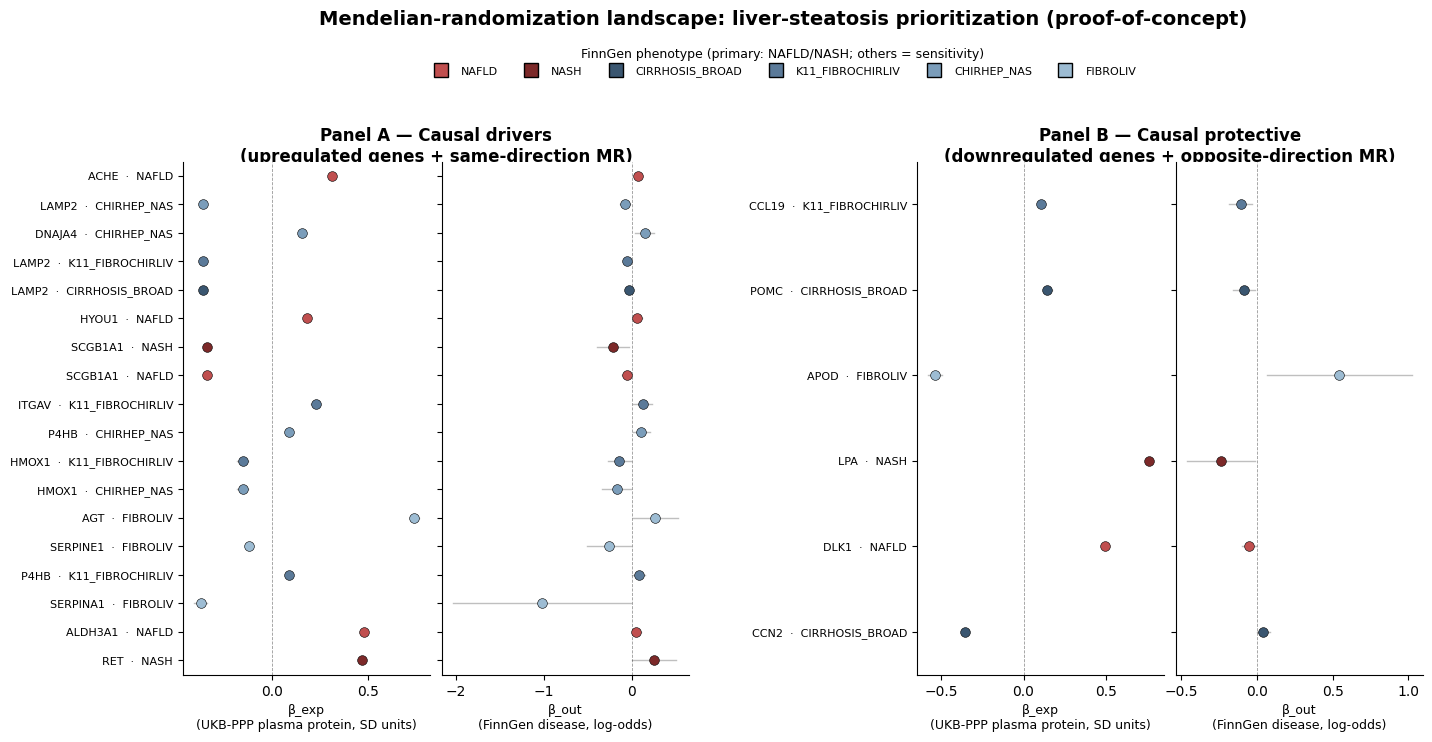

Saved: /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/output/figures/figure_S11.pdf
Panel A (drivers):    18 hits, 13 unique genes
Panel B (protective): 6 hits, 6 unique genes


In [20]:
import matplotlib.pyplot as plt
T = Config.TABLES_DIR

DRIVER_FILES  = ['mr_steatosis_up100_same_direction.csv']   # liver-steatosis-UP only
PROTECT_FILES = ['mr_steat_down_opposite_direction.csv']  # liver-steatosis-DOWN only

_st9 = pd.read_excel(ST7_FILE, sheet_name='ST9', header=4)
_st9['gene_symbol'] = _st9['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
SE_EXP_LOOKUP = (_st9[_st9['cis/trans'] == 'cis']
                 .drop_duplicates('gene_symbol')
                 .set_index('gene_symbol')['SE (discovery)'].to_dict())

def load_sig(files):
    rows = [pd.read_csv(T / n) for n in files]
    sig = pd.concat(rows, ignore_index=True)
    sig = sig[sig['p_MR'] < 0.05].copy()
    sig['SE_exp'] = sig['Gene'].map(SE_EXP_LOOKUP)
    return sig.sort_values('p_MR').reset_index(drop=True)

driver  = load_sig(DRIVER_FILES)
protect = load_sig(PROTECT_FILES)

phen_palette = {
    'NAFLD':            '#C04F4F',
    'NASH':             '#7C2929',
    'CIRRHOSIS_BROAD':  '#3A5670',
    'K11_FIBROCHIRLIV': '#5B7A99',
    'CHIRHEP_NAS':      '#7B9DBA',
    'FIBROLIV':         '#9DBCD3',
}

n_max = max(len(driver), len(protect), 1)
fig = plt.figure(figsize=(16, max(7, n_max * 0.32)))
outer = fig.add_gridspec(1, 2, wspace=0.45)

PANELS = [
    (driver,  'Panel A — Causal drivers\n(upregulated genes + same-direction MR)'),
    (protect, 'Panel B — Causal protective\n(downregulated genes + opposite-direction MR)'),
]

for panel_idx, (df, panel_title) in enumerate(PANELS):
    inner = outer[panel_idx].subgridspec(2, 2, height_ratios=[0.04, 1], hspace=0.02, wspace=0.05)
    title_ax = fig.add_subplot(inner[0, :]); title_ax.axis('off')
    title_ax.text(0.5, 0.5, panel_title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax_exp = fig.add_subplot(inner[1, 0])
    ax_out = fig.add_subplot(inner[1, 1], sharey=ax_exp)

    df = df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(df))
    for i, row in df.iterrows():
        c = phen_palette.get(row['Phenotype'], 'gray')
        se_exp = row['SE_exp']
        if pd.notna(se_exp):
            ax_exp.plot([row['beta_exp']-1.96*se_exp, row['beta_exp']+1.96*se_exp],
                        [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_exp.plot(row['beta_exp'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)
        ax_out.plot([row['beta_out']-1.96*row['SE'], row['beta_out']+1.96*row['SE']],
                    [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_out.plot(row['beta_out'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)

    ax_exp.set_yticks(y)
    ax_exp.set_yticklabels([f'{r.Gene}  ·  {r.Phenotype}' for _, r in df.iterrows()], fontsize=8)
    ax_out.tick_params(axis='y', labelleft=False)
    for ax in (ax_exp, ax_out):
        ax.axvline(0, color='black', ls='--', lw=0.6, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.set_ylim(-0.5, len(df) - 0.5)
    ax_exp.set_xlabel('β_exp\n(UKB-PPP plasma protein, SD units)', fontsize=9)
    ax_out.set_xlabel('β_out\n(FinnGen disease, log-odds)', fontsize=9)

phen_handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=10,
                            markeredgecolor='black', label=p)
                for p, c in phen_palette.items()]
fig.legend(handles=phen_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=6, frameon=False, title='FinnGen phenotype (primary: NAFLD/NASH; others = sensitivity)',
           fontsize=8, title_fontsize=9)
fig.suptitle('Mendelian-randomization landscape: liver-steatosis prioritization (proof-of-concept)', y=1.06, fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
out_pdf = Config.FIGURES_DIR / 'figure_S11.pdf'
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
print(f'Saved: {out_pdf}')
print(f'Panel A (drivers):    {len(driver)} hits, {driver.Gene.nunique()} unique genes')
print(f'Panel B (protective): {len(protect)} hits, {protect.Gene.nunique()} unique genes')

## 15.16 — External whole-blood cohort validation: Liver-cirrhosis on GSE142255 (source for NB16 Fig 4E)

In [ ]:
# 15.16 — External validation of the Liver-cirrhosis signature on GSE142255
# (Weiss et al. 2021, Front Immunol; whole blood, n=46). Source for NB16 Figure 4E.
# Method: GTEx Liver-cirrhosis PC-importance signature (top-K genes by NB11 importance),
# scored on GSE142255 as an importance-weighted sum of per-gene z-scored expression;
# direction-agnostic AUC = max(auc, 1 - auc).
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

_EXT = Config.ROOT_DIR / "data" / "external"
_expr = pd.read_csv(_EXT / "GSE142255" / "GSE142255_expression.csv.gz", index_col=0)
_meta = pd.read_csv(_EXT / "GSE142255" / "GSE142255_metadata.csv", index_col=0)
_pmap = pd.read_csv(_EXT / "GPL17586_probe_to_gene.csv")

# Probes -> gene (mean across probes per gene)
_em = _expr.join(_pmap.set_index("probe_id")["gene_symbol"], how="inner")
_scols = [c for c in _em.columns if c != "gene_symbol"]
_gene_expr = _em.groupby("gene_symbol")[_scols].mean()

# GTEx Liver-cirrhosis signature: top genes by PC-derived importance (NB11).
_sig = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
_sig_lc = _sig[(_sig["tissue"] == "Liver") & (_sig["category"] == "cirrhosis")] \
    .sort_values("importance", ascending=False)

# Labels: any cirrhosis stage = positive; healthy + septic-shock-no-cirrhosis = negative.
_stage = _meta["char stage of cirrhosis"].fillna("No") if "char stage of cirrhosis" in _meta.columns \
         else _meta["char_stage of cirrhosis"].fillna("No")
_labels = (_stage != "No").astype(int)

_rows, _per_k = [], {}
for _K in [50, 100, 200]:
    _top = _sig_lc.head(_K)
    _common = [g for g in _top["gene_name"] if g in _gene_expr.index]
    _tsub = _top[_top["gene_name"].isin(_common)].set_index("gene_name")
    _X = _gene_expr.loc[_common]
    _z = _X.subtract(_X.mean(axis=1), axis=0).divide(_X.std(axis=1).replace(0, np.nan), axis=0)
    _w = _tsub.loc[_common, "importance"].values
    _score = _z.T.dot(_w)
    _per_k[_K] = _score
    _a  = roc_auc_score(_labels, _score)
    _hc = (_meta["source_name"] == "Healthy subject") | (_labels == 1)
    _ss = (_meta["source_name"] == "Septic shock W/O cirrhosis") | (_labels == 1)
    _ahc = roc_auc_score(_labels[_hc], _score[_hc])
    _ass = roc_auc_score(_labels[_ss], _score[_ss])
    _rows.append({"K": _K, "n_matched": len(_common),
                  "AUC_all_46": round(max(_a, 1 - _a), 3),
                  "AUC_vs_healthy_only": round(max(_ahc, 1 - _ahc), 3),
                  "AUC_vs_septicshock_only": round(max(_ass, 1 - _ass), 3)})

_val = pd.DataFrame(_rows)
_val.to_csv(Config.TABLES_DIR / "external_validation_liver_cirrhosis_GSE142255.csv", index=False)

# Per-sample K=100 scores (sign-flipped to label direction) for the Fig 4E strip plot.
_s100 = _per_k[100]
if roc_auc_score(_labels, _s100) < 0.5:
    _s100 = -_s100
pd.DataFrame({
    "sample_id": _meta.index, "source_name": _meta["source_name"].values,
    "stage_of_cirrhosis": _stage.values, "label_binary": _labels.values,
    "signature_score": _s100.values,
}).to_csv(Config.TABLES_DIR / "external_scores_liver_cirrhosis_GSE142255.csv", index=False)

print("Saved external_validation + external_scores for GSE142255")
display(_val)